# Experiment 1: K-Means Clustering

Dataset: Iris dataset

## a) Load the dataset and split it into training and testing sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mode
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
data = pd.read_csv("../iris/iris.data", header=None, names=columns)

le = LabelEncoder()
data['species_encoded'] = le.fit_transform(data['species'])

X = data.drop(["species", "species_encoded"], axis=1)
y = data['species_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)


## b) Train a K-Means Clustering model (k=3) on the training data.

In [2]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

def map_clusters_to_labels(clusters, true_labels):
    labels = np.zeros_like(clusters)
    for i in range(3):
        mask = (clusters == i)
        if np.any(mask):
            m = mode(true_labels[mask], keepdims=True)
            labels[mask] = m.mode[0]
    return labels

train_clusters = kmeans.labels_
y_train_pred_km = map_clusters_to_labels(train_clusters, y_train.values)
print("K-Means Training Complete.")

K-Means Training Complete.


## c) Evaluate the model on the test set.

In [3]:
test_clusters_km = kmeans.predict(X_test_scaled)
y_test_pred_km = map_clusters_to_labels(test_clusters_km, y_test.values)

km_acc = accuracy_score(y_test, y_test_pred_km)
km_sil = silhouette_score(X_test_scaled, test_clusters_km)

print(f"K-Means Accuracy: {km_acc:.4f}")
print(f"K-Means Silhouette Score: {km_sil:.4f}")

K-Means Accuracy: 0.9000
K-Means Silhouette Score: 0.4520


# Experiment 2: Hierarchical Clustering

## a) Train a Hierarchical Clustering model.

In [4]:
hierarchical = AgglomerativeClustering(n_clusters=3)
train_clusters_hc = hierarchical.fit_predict(X_train_scaled)
y_train_pred_hc = map_clusters_to_labels(train_clusters_hc, y_train.values)
print("Hierarchical Training Complete.")

Hierarchical Training Complete.


## b) Evaluate the model.

In [5]:
test_clusters_hc = AgglomerativeClustering(n_clusters=3).fit_predict(X_test_scaled)
y_test_pred_hc = map_clusters_to_labels(test_clusters_hc, y_test.values)

hc_acc = accuracy_score(y_test, y_test_pred_hc)
hc_sil = silhouette_score(X_test_scaled, test_clusters_hc)

print(f"Hierarchical Accuracy: {hc_acc:.4f}")
print(f"Hierarchical Silhouette Score: {hc_sil:.4f}")

Hierarchical Accuracy: 0.9000
Hierarchical Silhouette Score: 0.4218


## c) Dendrogram Visualization.

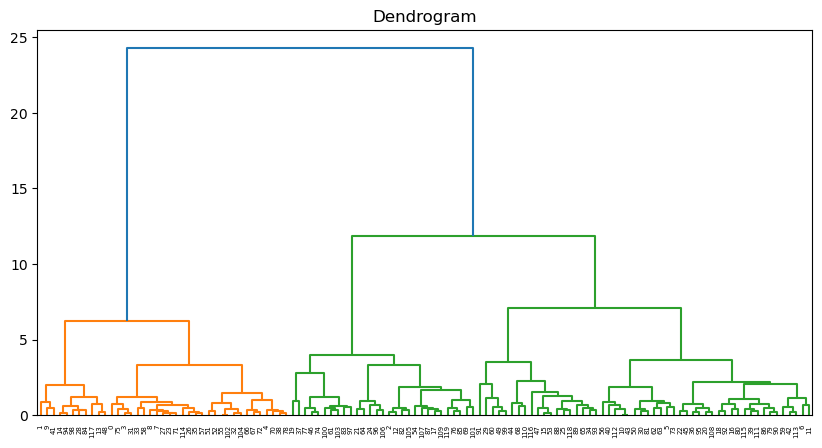

In [6]:
plt.figure(figsize=(10, 5))
linked = linkage(X_train_scaled, method='ward')
dendrogram(linked)
plt.title("Dendrogram")
plt.savefig('outputs/dendrogram.png', dpi=300)
plt.show()

# Experiment 3: Comparative Analysis

## a) Accuracy Comparison Bar Chart.

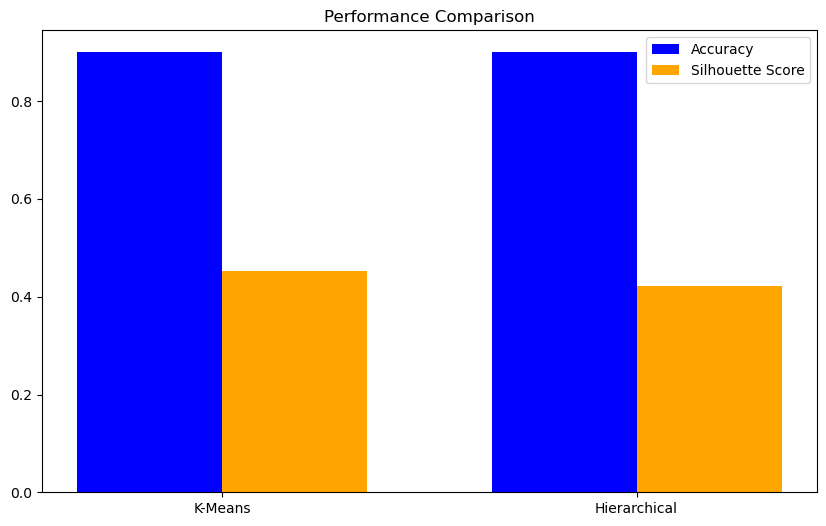

In [7]:
models = ['K-Means', 'Hierarchical']
accuracies = [km_acc, hc_acc]
silhouettes = [km_sil, hc_sil]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, accuracies, width, label='Accuracy', color='blue')
plt.bar(x + width/2, silhouettes, width, label='Silhouette Score', color='orange')
plt.xticks(x, models)
plt.legend()
plt.title('Performance Comparison')
plt.savefig('outputs/accuracy_comparison_8.png', dpi=300)
plt.show()

## b) Confusion Matrices.

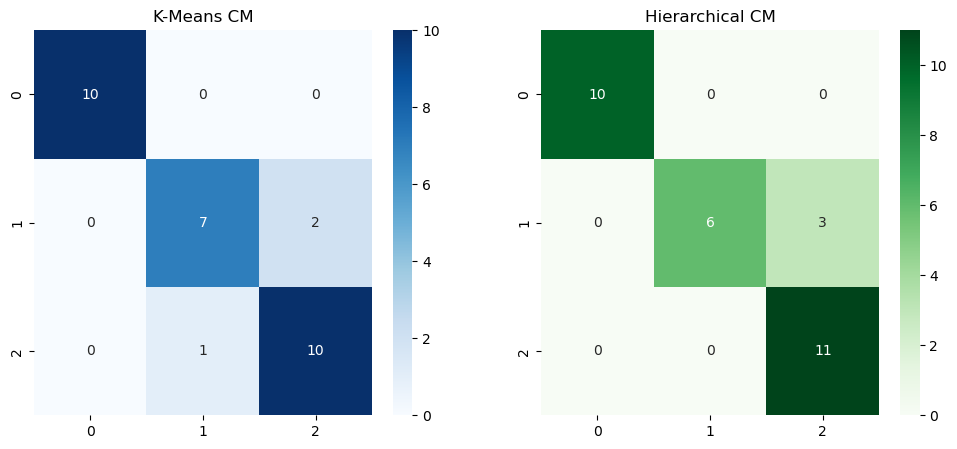

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_test_pred_km), annot=True, fmt='d', cmap='Blues')
plt.title("K-Means CM")
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_test_pred_hc), annot=True, fmt='d', cmap='Greens')
plt.title("Hierarchical CM")
plt.savefig('outputs/confusion_matrices_8.png', dpi=300)
plt.show()